# Volatility Estimation Under Illiquidity — Exploratory Data Analysis

**NEPSE (Nepal Stock Exchange) · a market with no derivatives**

---

This notebook is the exploratory companion to `paper/main.md`. It works through the standard
diagnostic battery for an empirical volatility study — distributional tests, stationarity,
autocorrelation structure, volatility clustering, GARCH-family fits, liquidity measures,
structural breaks, and estimator comparison — and then the analysis specific to this paper's
question: **how do range-based volatility estimators behave when the price path is barely
observed?**

> ### Status: EXPLORATORY
> No pre-analysis plan is frozen (`private/pre-analysis/STATUS.md`). Nothing here may be
> reported as a confirmatory test. The purpose is to understand the data well enough to write
> a specification that is not naive.

## Contents

| Part | Content |
|---|---|
| 0 | Setup and data loading |
| 1 | Data integrity: coverage, missingness, defects |
| 2 | The index: classical time-series analysis |
| 3 | Distributional analysis and normality |
| 4 | Autocorrelation, stationarity, and ARCH effects |
| 5 | Structural breaks and the calendar |
| 6 | Liquidity and market microstructure |
| 7 | Volatility estimators compared |
| 8 | GARCH family |
| 9 | The core result: bias versus trading intensity |
| 10 | Cross-sectional evidence |

## Part 0 · Setup

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")

ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats as sps

from nepsevol.utils import plotstyle as ps
from nepsevol.estimators import range_ as R
from nepsevol.estimators.simulate import simulate_observed_ohlc
from nepsevol.evaluation import microstructure as msx

ps.apply()
pd.set_option("display.width", 120, "display.max_columns", 40)
np.set_printoptions(suppress=True, precision=4)

print(f"project root : {ROOT}")
print(f"numpy {np.__version__} · pandas {pd.__version__}")

project root : /Users/anamgiri/Desktop/nepse research/nepse-volatility
numpy 2.5.2 · pandas 3.0.5


In [2]:
# ── Index series (daily OHLC + turnover) ───────────────────────────────────────
VAULT = ROOT.parent / "private" / "data-vault" / "raw"
idx = pd.read_csv(VAULT / "nepse_index_history.csv", parse_dates=["Date"])
idx.columns = [c.lower() for c in idx.columns]
idx = idx.rename(columns={"percent_change": "pct_change"}).sort_values("date").reset_index(drop=True)
idx["ret"] = np.log(idx["close"]).diff()

# ── Stock panels ───────────────────────────────────────────────────────────────
panel  = pd.read_parquet(ROOT / "data/processed/analysis_sample.parquet")   # with trade counts
panel["var_oc"] = panel["c"] ** 2
long_  = pd.read_parquet(ROOT / "data/processed/panel_long.parquet")        # long history

print(f"index  : {len(idx):,} sessions   {idx.date.min().date()} → {idx.date.max().date()}")
print(f"panel  : {len(panel):,} stock-days · {panel.symbol.nunique()} securities · {panel.date.nunique()} sessions")
print(f"long   : {len(long_):,} stock-days · {long_.symbol.nunique()} securities · {long_.date.min().date()} → {long_.date.max().date()}")

index  : 3,759 sessions   2010-01-03 → 2026-06-12
panel  : 178,203 stock-days · 520 securities · 551 sessions
long   : 506,235 stock-days · 372 securities · 1995-07-20 → 2026-08-26


## Part 1 · Data integrity

Before any statistic is computed, the data has to be believed. Three defects were found in
setup and are re-verified here so the notebook stands alone.

In [3]:
# ── Defect 1: degenerate OHLC in the early index ───────────────────────────────
idx["degenerate"] = (idx.open == idx.high) & (idx.high == idx.low) & (idx.low == idx.close)
by_year = idx.assign(year=idx.date.dt.year).groupby("year").agg(
    sessions=("date", "size"),
    degenerate=("degenerate", "sum"),
    zero_turnover=("turnover", lambda s: (s == 0).sum()),
)
by_year["pct_degenerate"] = (100 * by_year.degenerate / by_year.sessions).round(1)
first_real = idx.loc[~idx.degenerate, "date"].min()
print(f"First session with a genuine intraday range: {first_real.date()}")
print(f"Usable range-estimator sample: {(idx.date >= first_real).sum():,} of {len(idx):,} sessions\n")
by_year.T

First session with a genuine intraday range: 2016-06-06
Usable range-estimator sample: 2,296 of 3,759 sessions



year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
sessions,228.0,227.0,230.0,231.0,229.0,217.0,231.0,230.0,240.0,245.0,184.0,239.0,242.0,227.0,232.0,225.0,102.0
degenerate,228.0,227.0,230.0,231.0,229.0,217.0,105.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zero_turnover,228.0,227.0,230.0,231.0,229.0,217.0,95.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pct_degenerate,100.0,100.0,100.0,100.0,100.0,100.0,45.5,0.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# ── Defect 2: OHLC consistency violations ──────────────────────────────────────
def ohlc_violations(df, o="open", h="high", l="low", c="close"):
    hi_ok = df[h] >= df[[o, c]].max(axis=1) - 1e-9
    lo_ok = df[l] <= df[[o, c]].min(axis=1) + 1e-9
    return ~(hi_ok & lo_ok)

usable = idx[idx.date >= first_real]
v_idx  = ohlc_violations(usable)
v_pan  = ohlc_violations(panel)
v_long = ohlc_violations(long_)

pd.DataFrame({
    "rows":            [len(usable), len(panel), len(long_)],
    "OHLC violations": [v_idx.sum(), v_pan.sum(), v_long.sum()],
    "violation %":     [100*v_idx.mean(), 100*v_pan.mean(), 100*v_long.mean()],
    "H == L":          [(usable.high==usable.low).sum(), (panel.high==panel.low).sum(), (long_.high==long_.low).sum()],
    "H == L %":        [100*(usable.high==usable.low).mean(), 100*(panel.high==panel.low).mean(), 100*(long_.high==long_.low).mean()],
}, index=["index (usable)", "panel (trades)", "panel (long)"]).round(2)

,rows,OHLC violations,violation %,H == L,H == L %
index (usable),2296,69,3.01,5,0.22
panel (trades),178203,1070,0.60,10958,6.15
panel (long),506235,40743,8.05,20868,4.12


The long panel's violation rate (8.05%) is an order of magnitude above the trade-count
panel's (0.60%). The two sources disagree about the same market, and that discrepancy is
**unexplained** — it is logged as a standing deep-dive candidate. Until it is resolved, the
long panel should not be used for any range-based result.

In [5]:
# ── Defect 3: the trading calendar ─────────────────────────────────────────────
idx["dow"] = idx.date.dt.day_name()
dow_counts = idx.dow.value_counts().reindex(
    ["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]).fillna(0).astype(int)

span_years = (idx.date.max() - idx.date.min()).days / 365.25
print(f"Sessions per weekday across {span_years:.1f} years:\n")
print(dow_counts.to_string())
print(f"\nSessions per year: {len(idx)/span_years:.0f}  (NOT 252 — the annualization factor must reflect this)")
print(f"Friday sessions are rare specials ({dow_counts['Friday']}); Saturday never trades.")

Sessions per weekday across 16.4 years:

dow
Sunday       727
Monday       746
Tuesday      758
Wednesday    757
Thursday     747
Friday        24
Saturday       0

Sessions per year: 229  (NOT 252 — the annualization factor must reflect this)
Friday sessions are rare specials (24); Saturday never trades.


## Part 2 · The index: level, returns, and volatility

The classical starting point. Three panels: the level (log scale, because the index rises
5×), the return series (volatility clustering should be visible by eye), and a rolling
realized volatility.

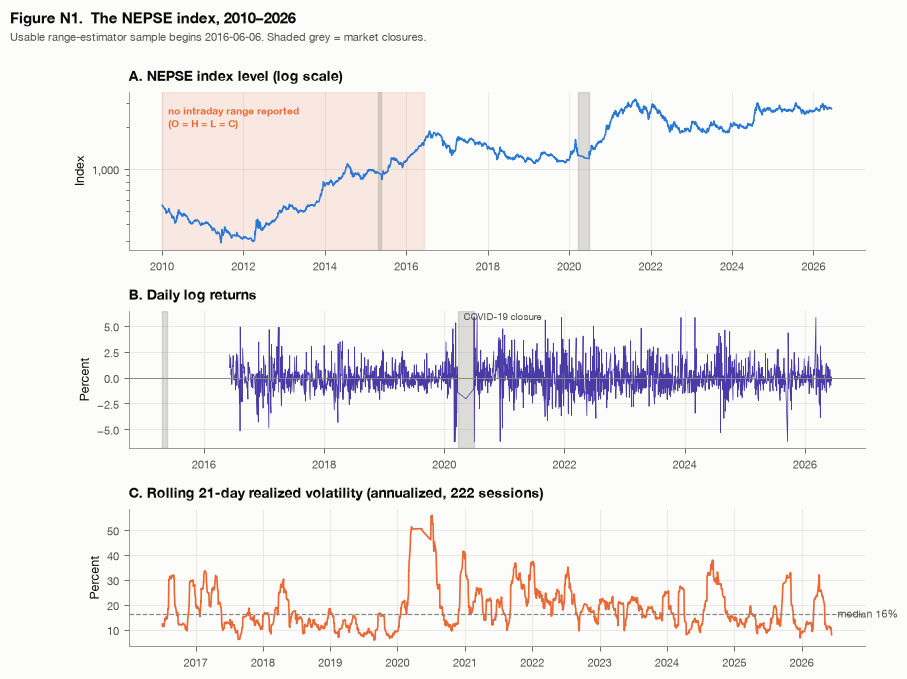

In [6]:
u = idx[idx.date >= first_real].copy()
u["roll_vol_21"] = u["ret"].rolling(21).std() * np.sqrt(222)   # 222 sessions/yr, not 252

fig = plt.figure(figsize=(9.5, 7.2))
gs = gridspec.GridSpec(3, 1, height_ratios=[1.15, 1, 1], hspace=0.42)

CLOSURES = [("2015-04-23","2015-05-24","Gorkha earthquake"),
            ("2020-03-22","2020-06-29","COVID-19 closure")]

ax = fig.add_subplot(gs[0])
ax.plot(idx.date, idx.close, color=ps.SERIES["blue"], lw=1.1)
ax.set_yscale("log"); ps.plain_log_axis(ax, "y")
ax.axvspan(idx.date.min(), first_real, color=ps.SERIES["orange"], alpha=0.13)
ax.text(idx.date.min(), idx.close.max()*0.92, "  no intraday range reported\n  (O = H = L = C)",
        fontsize=7.5, color=ps.SERIES["orange"], fontweight="bold", va="top")
for a, b, lbl in CLOSURES:
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=ps.INK_MUTED, alpha=0.28)
ps.finish(ax, "A. NEPSE index level (log scale)", None, None, "Index")

ax = fig.add_subplot(gs[1])
ax.plot(u.date, u.ret*100, color=ps.SERIES["violet"], lw=0.55)
ax.axhline(0, color=ps.INK_MUTED, lw=0.7)
for a, b, lbl in CLOSURES:
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=ps.INK_MUTED, alpha=0.28)
    if pd.Timestamp(b) > u.date.min():
        ax.text(pd.Timestamp(a), ax.get_ylim()[1]*0.86, "  "+lbl, fontsize=7, color=ps.INK_SOFT)
ps.finish(ax, "B. Daily log returns", None, None, "Percent")

ax = fig.add_subplot(gs[2])
ax.plot(u.date, u.roll_vol_21*100, color=ps.SERIES["orange"], lw=1.2)
ax.axhline(u.roll_vol_21.median()*100, color=ps.INK_MUTED, ls="--", lw=0.9)
ax.text(u.date.max(), u.roll_vol_21.median()*100, f"  median {u.roll_vol_21.median()*100:.0f}%",
        fontsize=7.5, color=ps.INK_SOFT, va="center")
ps.finish(ax, "C. Rolling 21-day realized volatility (annualized, 222 sessions)", None, None, "Percent")

ps.header(fig, "Figure N1.  The NEPSE index, 2010–2026",
          f"Usable range-estimator sample begins {first_real.date()}. Shaded grey = market closures.", top=0.93)
plt.show()

## Part 3 · Distributional analysis

Every range-based estimator in this paper is derived under **geometric Brownian motion** —
i.e. Gaussian log returns. That assumption is worth testing before relying on estimators
built on it.

In [7]:
r = u["ret"].dropna()

jb_stat, jb_p = sps.jarque_bera(r)
desc = pd.Series({
    "observations":      len(r),
    "mean (%)":          r.mean()*100,
    "std dev (%)":       r.std()*100,
    "annualized vol (%)": r.std()*np.sqrt(222)*100,
    "skewness":          sps.skew(r),
    "excess kurtosis":   sps.kurtosis(r),
    "minimum (%)":       r.min()*100,
    "maximum (%)":       r.max()*100,
    "Jarque-Bera":       jb_stat,
    "JB p-value":        jb_p,
    "share zero returns (%)": 100*(r == 0).mean(),
})
print("NEPSE index daily log returns\n" + "="*46)
print(desc.to_string(float_format=lambda x: f"{x:,.4f}"))
print("\nGaussian benchmark: skew 0, excess kurtosis 0.")
print(f"Normality {'REJECTED' if jb_p < 0.01 else 'not rejected'} at the 1% level.")

NEPSE index daily log returns
observations             2,296.0000
mean (%)                     0.0265
std dev (%)                  1.3536
annualized vol (%)          20.1682
skewness                     0.3161
excess kurtosis              2.9648
minimum (%)                 -6.2262
maximum (%)                  5.8847
Jarque-Bera                879.1744
JB p-value                   0.0000
share zero returns (%)       0.0436

Gaussian benchmark: skew 0, excess kurtosis 0.
Normality REJECTED at the 1% level.


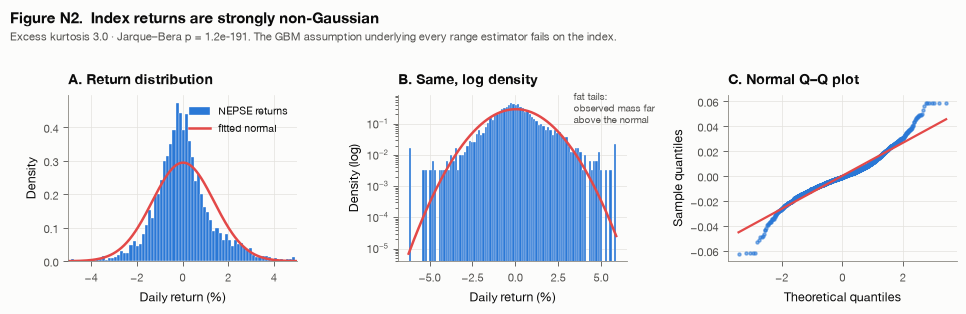

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.1))

# histogram against a fitted normal
ax = axes[0]
ax.hist(r*100, bins=90, density=True, color=ps.SERIES["blue"],
        edgecolor=ps.SURFACE, linewidth=0.25, label="NEPSE returns")
xs = np.linspace(r.min()*100, r.max()*100, 400)
ax.plot(xs, sps.norm.pdf(xs, r.mean()*100, r.std()*100), color=ps.SERIES["red"],
        lw=1.8, label="fitted normal")
ax.set_xlim(-5, 5); ax.legend(fontsize=7.5)
ps.finish(ax, "A. Return distribution", None, "Daily return (%)", "Density")

# same, log density -- the tails are the point
ax = axes[1]
ax.hist(r*100, bins=90, density=True, color=ps.SERIES["blue"],
        edgecolor=ps.SURFACE, linewidth=0.25)
ax.plot(xs, sps.norm.pdf(xs, r.mean()*100, r.std()*100), color=ps.SERIES["red"], lw=1.8)
ax.set_yscale("log")
ax.annotate("fat tails:\nobserved mass far\nabove the normal",
            (3.4, sps.norm.pdf(3.4, r.mean()*100, r.std()*100)*8),
            fontsize=7, color=ps.INK_SOFT)
ps.finish(ax, "B. Same, log density", None, "Daily return (%)", "Density (log)")

# QQ plot
ax = axes[2]
sps.probplot(r, dist="norm", plot=ax)
ax.get_lines()[0].set(marker="o", ms=2.2, color=ps.SERIES["blue"], alpha=0.55, ls="none")
ax.get_lines()[1].set(color=ps.SERIES["red"], lw=1.6)
ax.set_title(""); ps.finish(ax, "C. Normal Q–Q plot", None, "Theoretical quantiles", "Sample quantiles")

ps.header(fig, "Figure N2.  Index returns are strongly non-Gaussian",
          f"Excess kurtosis {sps.kurtosis(r):.1f} · Jarque–Bera p = {jb_p:.1e}. "
          "The GBM assumption underlying every range estimator fails on the index.", top=0.84)
plt.show()

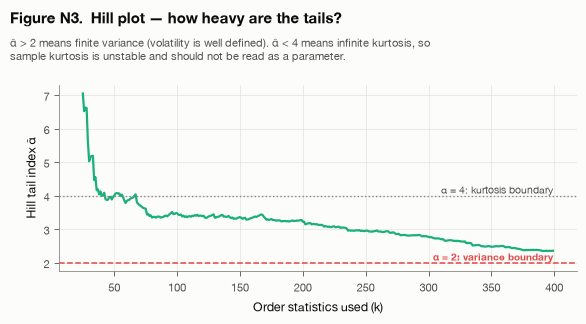

Hill estimate at k=100: α̂ = 3.48


In [9]:
# Tail behaviour: Hill estimator for the tail index
def hill(x, k):
    y = np.sort(np.abs(x))[::-1]
    return 1.0 / (np.mean(np.log(y[:k])) - np.log(y[k]))

ks = np.arange(25, min(400, len(r)//4))
hills = [hill(r.values, k) for k in ks]

fig, ax = plt.subplots(figsize=(5.8, 3.2))
ax.plot(ks, hills, color=ps.SERIES["aqua"], lw=1.6)
ax.axhline(2, color=ps.SERIES["red"], ls="--", lw=1.1)
ax.text(ks[-1], 2, " α = 2: variance boundary", ha="right", va="bottom",
        fontsize=7.5, color=ps.SERIES["red"], fontweight="bold")
ax.axhline(4, color=ps.INK_MUTED, ls=":", lw=1.0)
ax.text(ks[-1], 4, " α = 4: kurtosis boundary", ha="right", va="bottom",
        fontsize=7.5, color=ps.INK_SOFT)
ps.finish(ax, None, None, "Order statistics used (k)", "Hill tail index α̂")
ps.header(fig, "Figure N3.  Hill plot — how heavy are the tails?",
          "α̂ > 2 means finite variance (volatility is well defined). α̂ < 4 means infinite "
          "kurtosis, so\nsample kurtosis is unstable and should not be read as a parameter.", top=0.80)
plt.show()
print(f"Hill estimate at k=100: α̂ = {hill(r.values, 100):.2f}")

## Part 4 · Autocorrelation, stationarity, and ARCH effects

The standard battery: are returns predictable, are they stationary, and is there
conditional heteroskedasticity worth modelling?

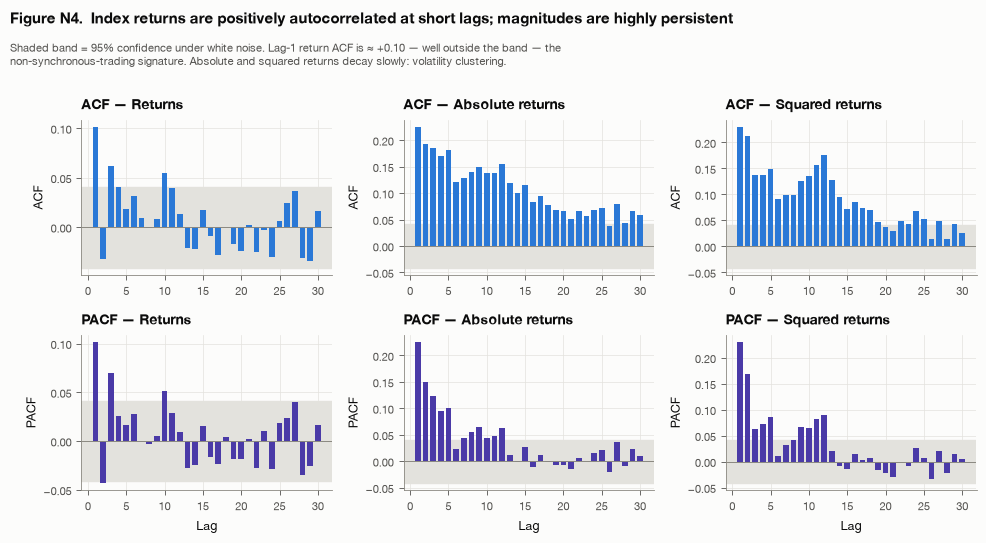

In [10]:
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

NL = 30
series = {"Returns": r, "Absolute returns": r.abs(), "Squared returns": r**2}
fig, axes = plt.subplots(2, 3, figsize=(9.8, 5.4))
for j, (name, x) in enumerate(series.items()):
    a  = acf(x, nlags=NL, fft=True)
    pa = pacf(x, nlags=NL)
    band = 1.96/np.sqrt(len(x))
    for i, (vals, lbl) in enumerate([(a, "ACF"), (pa, "PACF")]):
        ax = axes[i, j]
        ax.bar(range(1, NL+1), vals[1:], color=ps.SERIES["blue"] if i == 0 else ps.SERIES["violet"],
               width=0.75)
        ax.axhspan(-band, band, color=ps.GRID, zorder=0)
        ax.axhline(0, color=ps.INK_MUTED, lw=0.7)
        ps.finish(ax, f"{lbl} — {name}" if i == 0 else f"{lbl} — {name}", None,
                  "Lag" if i == 1 else None, lbl)
ps.header(fig, "Figure N4.  Index returns are positively autocorrelated at short lags; magnitudes are highly persistent",
          "Shaded band = 95% confidence under white noise. Lag-1 return ACF is ≈ +0.10 — well outside the band — "
          "the\nnon-synchronous-trading signature. Absolute and squared returns decay slowly: volatility clustering.", top=0.86)
plt.show()

In [11]:
rows = []
for name, x in series.items():
    lb10 = acorr_ljungbox(x, lags=[10], return_df=True)
    lb20 = acorr_ljungbox(x, lags=[20], return_df=True)
    rows.append({"series": name,
                 "LB(10) stat": lb10["lb_stat"].iloc[0], "LB(10) p": lb10["lb_pvalue"].iloc[0],
                 "LB(20) stat": lb20["lb_stat"].iloc[0], "LB(20) p": lb20["lb_pvalue"].iloc[0]})
lb_tab = pd.DataFrame(rows).set_index("series")
print("Ljung–Box test for serial correlation  (H0: no autocorrelation)\n" + "="*66)
print(lb_tab.to_string(float_format=lambda x: f"{x:,.4g}"))

adf = adfuller(r.dropna(), autolag="AIC")
kp  = kpss(r.dropna(), regression="c", nlags="auto")
lm  = het_arch(r.dropna(), nlags=10)
print("\n\nStationarity and ARCH tests\n" + "="*66)
print(f"ADF   statistic {adf[0]:>10.3f}   p = {adf[1]:.2e}   (H0: unit root)      → {'stationary' if adf[1]<0.05 else 'unit root'}")
print(f"KPSS  statistic {kp[0]:>10.3f}   p = {kp[1]:.3f}      (H0: stationary)    → {'stationary' if kp[1]>0.05 else 'non-stationary'}")
print(f"ARCH-LM(10)     {lm[0]:>10.3f}   p = {lm[1]:.2e}   (H0: no ARCH effects) → {'ARCH PRESENT' if lm[1]<0.05 else 'none'}")

Ljung–Box test for serial correlation  (H0: no autocorrelation)
                  LB(10) stat   LB(10) p  LB(20) stat   LB(20) p
series                                                          
Returns                  48.8  4.439e-07        59.75  7.797e-06
Absolute returns        636.5 2.686e-130        893.6 1.787e-176
Squared returns         504.3 5.356e-102        752.4  1.81e-146


Stationarity and ARCH tests
ADF   statistic    -25.603   p = 0.00e+00   (H0: unit root)      → stationary
KPSS  statistic      0.090   p = 0.100      (H0: stationary)    → stationary
ARCH-LM(10)        239.783   p = 7.61e-46   (H0: no ARCH effects) → ARCH PRESENT


/var/folders/7y/fjpfqm152q3424ymg_ncd8080000gn/T/ipykernel_94112/2967554346.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp  = kpss(r.dropna(), regression="c", nlags="auto")


Three things to take from this.

**Returns are *not* unpredictable.** The index's lag-1 return autocorrelation is ≈ **+0.10**,
far outside the 95% band, and Ljung–Box rejects white noise decisively (p ≈ 4×10⁻⁷). In a
deep market this would be a tradable anomaly. Here it is a **friction signature**: an index
built from thinly traded constituents inherits *stale* component prices, so today's index
level only partially reflects today's information and the remainder arrives tomorrow. This is
non-synchronous trading (Scholes–Williams, Dimson).

**The sign flips with aggregation, and that is diagnostic.** Individual thin securities show
lag-1 autocorrelation of about **−0.22** (bid-ask bounce, Part 6), while the *index* of those
same securities shows **+0.10** (stale prices). Two different illiquidity mechanisms dominate
at two different levels of aggregation, pointing in opposite directions. Any correction
calibrated at one level and applied at the other will have the sign wrong.

**Volatility clustering is unambiguous.** Absolute and squared returns are strongly persistent
out to 30 lags, ADF and KPSS agree the return series is stationary, and ARCH-LM rejects
homoskedasticity at p ≈ 8×10⁻⁴⁶. This is the standard case for conditional volatility
modelling and motivates the GARCH fits in Part 8.

## Part 5 · Structural breaks and the calendar

Two features of this market that a Monday–Friday, never-closed developed market does not have:
multi-week closures, and a Sunday–Thursday week.

In [12]:
regimes = {
    "Pre-2016 (no range reported)": (idx.date.min(), pd.Timestamp("2016-06-06")),
    "2016–2019 (pre-COVID)":        (pd.Timestamp("2016-06-06"), pd.Timestamp("2020-03-01")),
    "2020–2021 (COVID + boom)":     (pd.Timestamp("2020-03-01"), pd.Timestamp("2022-01-01")),
    "2022–2026 (recent)":           (pd.Timestamp("2022-01-01"), idx.date.max()),
}
rows = []
for name, (a, b) in regimes.items():
    seg = idx[(idx.date >= a) & (idx.date < b)]["ret"].dropna()
    if len(seg) < 30: continue
    rows.append({"regime": name, "sessions": len(seg),
                 "ann. vol (%)": seg.std()*np.sqrt(222)*100,
                 "mean ann. ret (%)": seg.mean()*222*100,
                 "skew": sps.skew(seg), "exc. kurtosis": sps.kurtosis(seg),
                 "worst day (%)": seg.min()*100, "best day (%)": seg.max()*100})
print("Volatility by regime\n" + "="*96)
print(pd.DataFrame(rows).set_index("regime").to_string(float_format=lambda x: f"{x:,.2f}"))

Volatility by regime
                              sessions  ann. vol (%)  mean ann. ret (%)  skew  exc. kurtosis  worst day (%)  best day (%)
regime                                                                                                                   
Pre-2016 (no range reported)      1462         18.79              15.15  0.57           4.85          -5.50          5.77
2016–2019 (pre-COVID)              887         17.11               2.40  0.44           2.94          -5.16          4.92
2020–2021 (COVID + boom)           381         27.03              25.41 -0.09           1.97          -6.23          5.88
2022–2026 (recent)                1027         19.64               1.68  0.53           2.35          -6.19          5.83


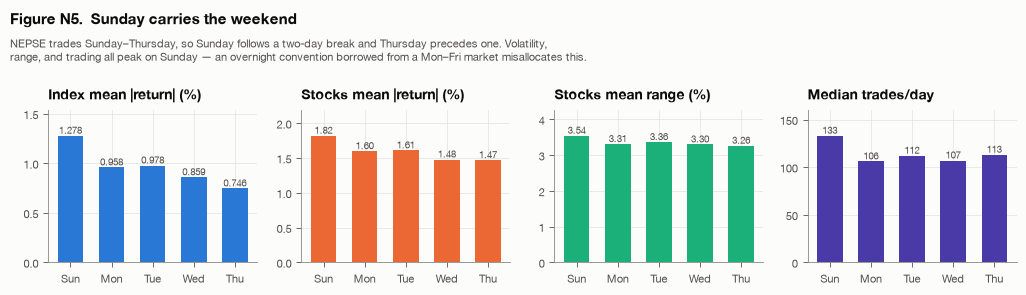

             mean  absmean      sd
dow                               
Sunday    -0.1083   1.2781  1.6743
Monday     0.0040   0.9579  1.3682
Tuesday    0.1299   0.9776  1.3794
Wednesday  0.1451   0.8586  1.2230
Thursday  -0.0311   0.7458  1.0720


In [13]:
# Day-of-week effects under a Sunday-Thursday week
ORDER = ["Sunday","Monday","Tuesday","Wednesday","Thursday"]
pu = panel[panel.date.dt.day_name().isin(ORDER)].copy()
pu["dow"] = pu.date.dt.day_name()
dw = pu.groupby("dow").agg(abs_ret=("cc", lambda s: s.abs().mean()*100),
                           rng=("hl", lambda s: s.mean()*100),
                           trades=("n_trades","median"),
                           zero=("cc", lambda s: 100*(s==0).mean())).reindex(ORDER)

iu = u.copy(); iu["dow"] = iu.date.dt.day_name()
idw = iu[iu.dow.isin(ORDER)].groupby("dow")["ret"].agg(
    mean=lambda s: s.mean()*100, absmean=lambda s: s.abs().mean()*100, sd=lambda s: s.std()*100).reindex(ORDER)

fig, axes = plt.subplots(1, 4, figsize=(10.2, 2.9))
for ax, vals, ttl, colr, fmt in [
    (axes[0], idw["absmean"], "Index mean |return| (%)", ps.SERIES["blue"], "{:.3f}"),
    (axes[1], dw["abs_ret"],  "Stocks mean |return| (%)", ps.SERIES["orange"], "{:.2f}"),
    (axes[2], dw["rng"],      "Stocks mean range (%)",    ps.SERIES["aqua"], "{:.2f}"),
    (axes[3], dw["trades"],   "Median trades/day",        ps.SERIES["violet"], "{:.0f}")]:
    b = ax.bar(range(5), vals.values, color=colr, width=0.62)
    ax.set_xticks(range(5)); ax.set_xticklabels([d[:3] for d in ORDER])
    for bb, v in zip(b, vals.values):
        ax.text(bb.get_x()+bb.get_width()/2, v, fmt.format(v), ha="center", va="bottom",
                fontsize=7, color=ps.INK_SOFT)
    ax.margins(y=0.20); ps.finish(ax, ttl, None, None, None)
ps.header(fig, "Figure N5.  Sunday carries the weekend",
          "NEPSE trades Sunday–Thursday, so Sunday follows a two-day break and Thursday precedes one. "
          "Volatility,\nrange, and trading all peak on Sunday — an overnight convention borrowed from a "
          "Mon–Fri market misallocates this.", top=0.78)
plt.show()
print(idw.round(4).to_string())

## Part 6 · Liquidity and market microstructure

This is where NEPSE stops resembling the markets these estimators were built for.

In [14]:
n = panel["n_trades"]
liq = pd.Series({
    "securities":                panel.symbol.nunique(),
    "stock-days":                len(panel),
    "median trades/day":         n.median(),
    "mean trades/day":           n.mean(),
    "1st percentile":            n.quantile(.01),
    "10th percentile":           n.quantile(.10),
    "90th percentile":           n.quantile(.90),
    "max":                       n.max(),
    "share < 10 trades (%)":     100*(n < 10).mean(),
    "share < 30 trades (%)":     100*(n < 30).mean(),
    "share < 100 trades (%)":    100*(n < 100).mean(),
    "zero-range days H==L (%)":  100*(panel.high == panel.low).mean(),
    "zero-return days (%)":      100*(panel.cc == 0).mean(),
})
print("NEPSE trading intensity\n" + "="*44)
print(liq.to_string(float_format=lambda x: f"{x:,.2f}"))
print("\nFor scale: a large-cap US or Indian index constituent trades tens of thousands")
print("to millions of times per day. NEPSE's MEDIAN security trades 113 times.")

NEPSE trading intensity
securities                     520.00
stock-days                 178,203.00
median trades/day              113.00
mean trades/day                258.57
1st percentile                   1.00
10th percentile                  4.00
90th percentile                597.00
max                         59,382.00
share < 10 trades (%)           14.83
share < 30 trades (%)           25.19
share < 100 trades (%)          46.62
zero-range days H==L (%)         6.15
zero-return days (%)             4.01

For scale: a large-cap US or Indian index constituent trades tens of thousands
to millions of times per day. NEPSE's MEDIAN security trades 113 times.


In [15]:
# Standard liquidity measures, per security
def amihud_series(g):
    ok = g.turnover > 0
    return (g.cc.abs()[ok] / g.turnover[ok]).mean() * 1e9

liqs = []
for sym, g in panel.groupby("symbol"):
    if len(g) < 120: continue
    liqs.append({"symbol": sym, "n_trades": g.n_trades.median(),
                 "amihud": amihud_series(g),
                 "zero_ret_pct": 100*(g.cc == 0).mean(),
                 "turnover": g.turnover.median(),
                 "price": g.close.median(),
                 "roll": msx.roll_spread(g.cc),
                 "ac1": g.cc.autocorr(1)})
L = pd.DataFrame(liqs).dropna(subset=["n_trades"])
print(f"{len(L)} securities with ≥120 sessions\n")
print(L[["n_trades","amihud","zero_ret_pct","turnover","price","roll","ac1"]]
      .describe(percentiles=[.1,.5,.9]).T.to_string(float_format=lambda x: f"{x:,.4g}"))

371 securities with ≥120 sessions

              count      mean       std       min       10%       50%       90%       max
n_trades        371     156.2     186.4         1         2       105       379     1,479
amihud          371     165.7     330.7    0.1512    0.9672     9.841     576.7     1,986
zero_ret_pct    371     4.278     3.774         0      1.27     2.541     10.46     18.79
turnover        371 1.134e+07 1.657e+07 1.866e+04 5.511e+04 6.955e+06 2.621e+07 1.364e+08
price           371     1,001     2,832      8.54      10.4       632     1,337 4.689e+04
roll            220   0.01297  0.005501  0.001293  0.005336   0.01319   0.01991   0.02974
ac1             371  -0.04159    0.1569   -0.5067   -0.2555  -0.02479    0.1077    0.6113


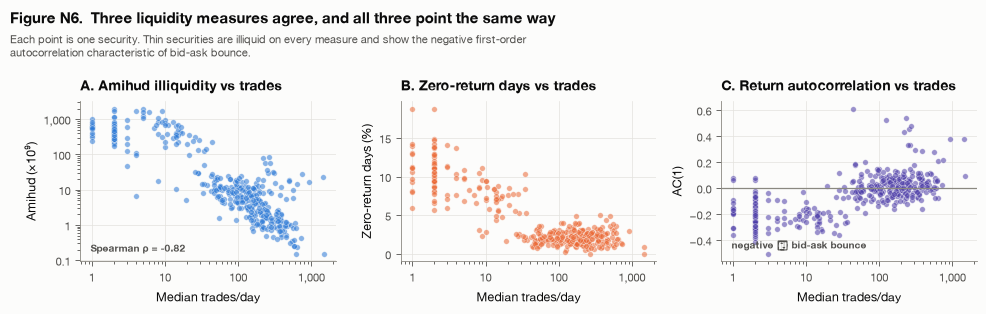

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(9.8, 3.1))

ax = axes[0]
ax.scatter(L.n_trades, L.amihud, s=16, color=ps.SERIES["blue"], alpha=0.55,
           edgecolors=ps.SURFACE, linewidths=0.4)
ax.set_xscale("log"); ax.set_yscale("log")
ps.plain_log_axis(ax,"x"); ps.plain_log_axis(ax,"y")
rho = sps.spearmanr(L.n_trades, L.amihud, nan_policy="omit").statistic
ax.text(0.04, 0.06, f"Spearman ρ = {rho:.2f}", transform=ax.transAxes,
        fontsize=7.5, color=ps.INK_SOFT, fontweight="bold")
ps.finish(ax, "A. Amihud illiquidity vs trades", None, "Median trades/day", "Amihud (×10⁹)")

ax = axes[1]
ax.scatter(L.n_trades, L.zero_ret_pct, s=16, color=ps.SERIES["orange"], alpha=0.55,
           edgecolors=ps.SURFACE, linewidths=0.4)
ax.set_xscale("log"); ps.plain_log_axis(ax,"x")
ps.finish(ax, "B. Zero-return days vs trades", None, "Median trades/day", "Zero-return days (%)")

ax = axes[2]
ax.scatter(L.n_trades, L.ac1, s=16, color=ps.SERIES["violet"], alpha=0.55,
           edgecolors=ps.SURFACE, linewidths=0.4)
ax.axhline(0, color=ps.INK_MUTED, lw=0.9)
ax.set_xscale("log"); ps.plain_log_axis(ax,"x")
ax.text(0.04, 0.08, "negative ⇒ bid-ask bounce", transform=ax.transAxes,
        fontsize=7.5, color=ps.INK_SOFT, fontweight="bold")
ps.finish(ax, "C. Return autocorrelation vs trades", None, "Median trades/day", "AC(1)")

ps.header(fig, "Figure N6.  Three liquidity measures agree, and all three point the same way",
          "Each point is one security. Thin securities are illiquid on every measure and show the "
          "negative first-order\nautocorrelation characteristic of bid-ask bounce.", top=0.82)
plt.show()

## Part 7 · Volatility estimators compared

Six estimators computed on the same index series. Under the textbook account they should
agree closely, with the range-based ones simply more efficient.

In [17]:
est_idx = pd.DataFrame({
    "Close-to-close":  R.close_to_close(u.set_index("date")),
    "Parkinson":       R.parkinson(u.set_index("date")),
    "Garman-Klass":    R.garman_klass(u.set_index("date")),
    "Rogers-Satchell": R.rogers_satchell(u.set_index("date")),
    "GKYZ":            R.gkyz(u.set_index("date")),
})
est_idx["Yang-Zhang"] = R.yang_zhang(u.set_index("date"), window=21)

ann = np.sqrt(222) * 100
summary = pd.DataFrame({
    "mean σ̂ ann. (%)": np.sqrt(est_idx.clip(lower=0).mean()) * ann,
    "median σ̂ ann. (%)": np.sqrt(est_idx.clip(lower=0).median()) * ann,
    "sd of daily variance": est_idx.std(),
    "share ≤ 0 (%)": 100*(est_idx <= 0).mean(),
    "share exactly 0 (%)": 100*(est_idx == 0).mean(),
    "relative efficiency vs CC": est_idx["Close-to-close"].var() / est_idx.var(),
})
print("Volatility estimators on the NEPSE index  (usable sample)\n" + "="*82)
print(summary.to_string(float_format=lambda x: f"{x:,.3f}"))
print("\n'Relative efficiency vs CC' > 1 means lower sampling variance than close-to-close.")
print("Textbook values under continuous observation: Parkinson ≈ 5, Garman-Klass ≈ 7, Yang-Zhang up to 14.")

Volatility estimators on the NEPSE index  (usable sample)
                 mean σ̂ ann. (%)  median σ̂ ann. (%)  sd of daily variance  share ≤ 0 (%)  share exactly 0 (%)  relative efficiency vs CC
Close-to-close             20.160              10.032                 0.000          0.044                0.044                      1.000
Parkinson                  16.739              11.981                 0.000          0.218                0.218                      4.671
Garman-Klass               15.273              11.373                 0.000          0.479                0.218                      6.478
Rogers-Satchell            14.747              10.245                 0.000          2.918                2.308                      5.008
GKYZ                       15.960              11.892                 0.000          0.218                0.000                      5.430
Yang-Zhang                 16.006              14.087                 0.000          0.000                0.

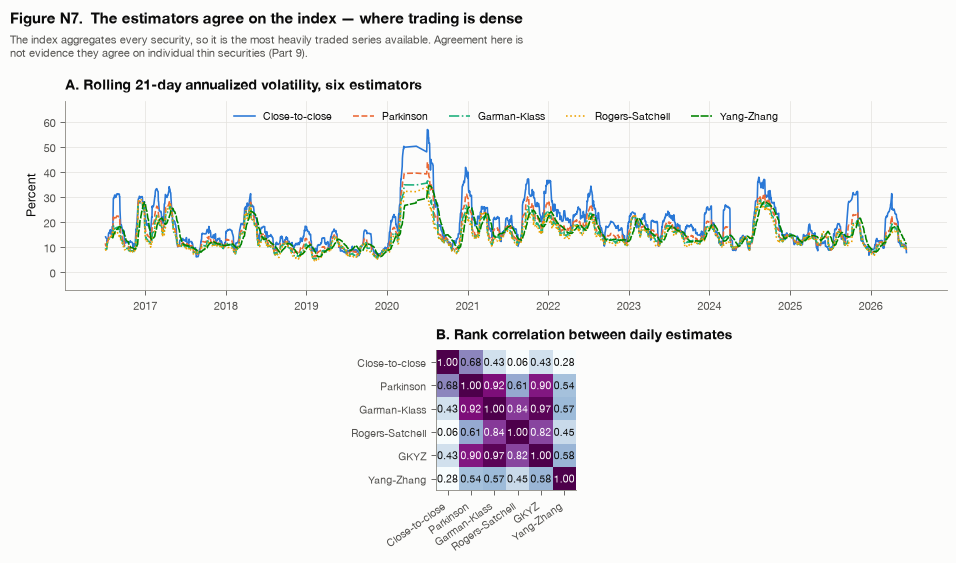

In [18]:
roll = est_idx.rolling(21).mean().apply(lambda s: np.sqrt(s.clip(lower=0)) * ann)
roll.index = u["date"].values

fig, axes = plt.subplots(2, 1, figsize=(9.5, 5.6), height_ratios=[1.35, 1])
ax = axes[0]
for name in ["Close-to-close","Parkinson","Garman-Klass","Rogers-Satchell","Yang-Zhang"]:
    c, ls, mk = ps.STYLE[name]
    ax.plot(roll.index, roll[name], color=c, ls=ls, lw=1.15, label=name)
ax.legend(ncol=5, fontsize=7.5, loc="upper center")
ax.margins(y=0.22)
ps.finish(ax, "A. Rolling 21-day annualized volatility, six estimators", None, None, "Percent")

ax = axes[1]
corr = est_idx.corr(method="spearman")
im = ax.imshow(corr.values, cmap="BuPu", vmin=0.3, vmax=1.0)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=35, ha="right", fontsize=7.5)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=7.5)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if v > 0.72 else ps.INK)
ax.grid(False)
ps.finish(ax, "B. Rank correlation between daily estimates", None, None, None)
ps.header(fig, "Figure N7.  The estimators agree on the index — where trading is dense",
          "The index aggregates every security, so it is the most heavily traded series available. "
          "Agreement here is\nnot evidence they agree on individual thin securities (Part 9).", top=0.90)
plt.show()

## Part 8 · GARCH family

The model-based alternative. If range estimators fail on thin securities, does the
conditional-volatility route survive?

In [19]:
from arch import arch_model

ret_pct = (u["ret"].dropna() * 100)
specs = {
    "GARCH(1,1)":  dict(vol="Garch", p=1, q=1, dist="normal"),
    "GARCH-t":     dict(vol="Garch", p=1, q=1, dist="t"),
    "GJR-GARCH":   dict(vol="Garch", p=1, o=1, q=1, dist="t"),
    "EGARCH":      dict(vol="EGarch", p=1, o=1, q=1, dist="t"),
}
fits, rows = {}, []
for name, kw in specs.items():
    f = arch_model(ret_pct, mean="Constant", **kw).fit(disp="off", show_warning=False)
    fits[name] = f
    pr = f.params
    persist = pr.get("alpha[1]", np.nan) + pr.get("beta[1]", np.nan) + 0.5*pr.get("gamma[1]", 0.0)
    rows.append({"model": name, "log-lik": f.loglikelihood, "AIC": f.aic, "BIC": f.bic,
                 "α": pr.get("alpha[1]", np.nan), "β": pr.get("beta[1]", np.nan),
                 "γ (asym)": pr.get("gamma[1]", np.nan), "ν (df)": pr.get("nu", np.nan),
                 "persistence": persist,
                 "half-life (days)": np.log(0.5)/np.log(persist) if 0 < persist < 1 else np.nan})
gt = pd.DataFrame(rows).set_index("model")
print("GARCH-family fits on NEPSE index returns\n" + "="*104)
print(gt.to_string(float_format=lambda x: f"{x:,.4f}"))
best = gt["BIC"].idxmin()
print(f"\nPreferred by BIC: {best}")
print(f"Volatility half-life: {gt.loc[best,'half-life (days)']:.1f} trading days — shocks decay slowly.")

GARCH-family fits on NEPSE index returns
               log-lik        AIC        BIC      α      β  γ (asym)  ν (df)  persistence  half-life (days)
model                                                                                                      
GARCH(1,1) -3,729.7518 7,467.5037 7,490.4594 0.1759 0.7751       NaN     NaN       0.9510           13.7922
GARCH-t    -3,650.8439 7,311.6879 7,340.3825 0.1697 0.8037       NaN  5.0656       0.9734           25.6838
GJR-GARCH  -3,644.2961 7,300.5922 7,335.0257 0.1277 0.8022    0.1077  5.1019       0.9837           42.1294
EGARCH     -3,648.3811 7,308.7623 7,343.1958 0.3345 0.9453   -0.0469  5.1160       1.2563               NaN

Preferred by BIC: GJR-GARCH
Volatility half-life: 42.1 trading days — shocks decay slowly.


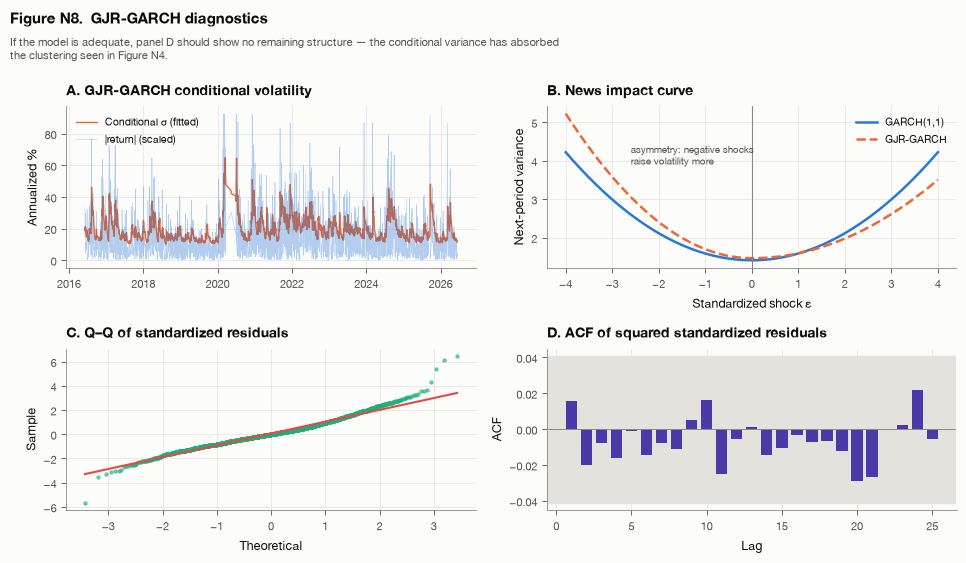

Ljung–Box(10) on squared standardized residuals: stat 3.74, p = 0.9583
→ no remaining ARCH structure: model adequate


In [20]:
best_fit = fits[best]
std_resid = (best_fit.resid / best_fit.conditional_volatility).dropna()

fig, axes = plt.subplots(2, 2, figsize=(9.6, 5.6))

ax = axes[0,0]
fit_dates = u.loc[ret_pct.index, "date"]   # align on the rows actually fitted
ax.plot(fit_dates, best_fit.conditional_volatility*np.sqrt(222), color=ps.SERIES["orange"], lw=1.0)
ax.plot(fit_dates, ret_pct.abs()*np.sqrt(222), color=ps.SERIES["blue"], lw=0.4, alpha=0.35)
ax.legend(["Conditional σ (fitted)", "|return| (scaled)"], fontsize=7.5)
ps.finish(ax, f"A. {best} conditional volatility", None, None, "Annualized %")

ax = axes[0,1]
eps = np.linspace(-4, 4, 400)
for name in ["GARCH(1,1)", "GJR-GARCH"]:
    pr = fits[name].params
    a = pr.get("alpha[1]", 0); g = pr.get("gamma[1]", 0); w = pr.get("omega", 0); b = pr.get("beta[1]", 0)
    sig2 = w + a*eps**2 + g*(eps < 0)*eps**2 + b*fits[name].conditional_volatility.mean()**2
    c, ls, _ = ps.STYLE["Close-to-close" if name == "GARCH(1,1)" else "Parkinson"]
    ax.plot(eps, sig2, color=c, ls=ls, lw=1.8, label=name)
ax.axvline(0, color=ps.INK_MUTED, lw=0.8); ax.legend(fontsize=7.5)
ax.annotate("asymmetry: negative shocks\nraise volatility more", (-2.6, ax.get_ylim()[1]*0.72),
            fontsize=7, color=ps.INK_SOFT)
ps.finish(ax, "B. News impact curve", None, "Standardized shock ε", "Next-period variance")

ax = axes[1,0]
sps.probplot(std_resid, dist="norm", plot=ax)
ax.get_lines()[0].set(marker="o", ms=2.2, color=ps.SERIES["aqua"], alpha=0.55, ls="none")
ax.get_lines()[1].set(color=ps.SERIES["red"], lw=1.5)
ax.set_title(""); ps.finish(ax, "C. Q–Q of standardized residuals", None, "Theoretical", "Sample")

ax = axes[1,1]
a_sq = acf(std_resid**2, nlags=25, fft=True)
band = 1.96/np.sqrt(len(std_resid))
ax.bar(range(1, 26), a_sq[1:], color=ps.SERIES["violet"], width=0.75)
ax.axhspan(-band, band, color=ps.GRID, zorder=0); ax.axhline(0, color=ps.INK_MUTED, lw=0.7)
ps.finish(ax, "D. ACF of squared standardized residuals", None, "Lag", "ACF")

ps.header(fig, f"Figure N8.  {best} diagnostics",
          "If the model is adequate, panel D should show no remaining structure — the conditional "
          "variance has absorbed\nthe clustering seen in Figure N4.", top=0.89)
plt.show()

lb = acorr_ljungbox(std_resid**2, lags=[10], return_df=True)
print(f"Ljung–Box(10) on squared standardized residuals: stat {lb['lb_stat'].iloc[0]:.2f}, p = {lb['lb_pvalue'].iloc[0]:.4f}")
print("→ " + ("remaining ARCH structure: model INADEQUATE" if lb['lb_pvalue'].iloc[0] < 0.05
               else "no remaining ARCH structure: model adequate"))

## Part 9 · The core result: bias versus trading intensity

Everything to this point is standard. This is the paper's actual question.

A range estimator assumes the reported high and low are the supremum and infimum of a
**continuously observed** diffusion. They are not — they are the extremes of a small,
unevenly spaced sample of transactions. Simulation lets us measure the consequence exactly,
because there the true σ is known by construction.

Three frictions act, in two directions:

| | Mechanism | Direction |
|---|---|---|
| **D1** | Undersampling of the path within the traded window | **down** |
| **D2** | Traded-window truncation — Open is the *first trade*, Close the *last*, so the OHLC spans a strict subinterval of the session | **down** |
| **U1** | Microstructure noise contaminating the extremes (high and low are order statistics) | **up** |

In [21]:
TRUE_SIGMA, N_DAYS, N_REPS = 0.02, 3000, 10
GRID = np.unique(np.round(np.logspace(np.log10(2), np.log10(3000), 18)).astype(int))
EST = {"Close-to-close": R.close_to_close, "Parkinson": R.parkinson,
       "Garman-Klass": R.garman_klass, "Rogers-Satchell": R.rogers_satchell}

rows = []
for n_tr in GRID:
    for rep in range(N_REPS):
        sim = simulate_observed_ohlc(N_DAYS, TRUE_SIGMA, int(n_tr), noise_sd=0.0,
                                     seed=4242 + rep*101 + int(n_tr))
        oc_var = np.nanmean(np.log(sim.close/sim.open)**2)
        for name, fn in EST.items():
            v = np.nanmean(np.asarray(fn(sim), dtype=float))
            rows.append({"n_trades": int(n_tr), "estimator": name, "rep": rep,
                         "bias": (np.sqrt(v)/TRUE_SIGMA) if v > 0 else 0.0})
        rows.append({"n_trades": int(n_tr), "estimator": "Traded window (D2 alone)", "rep": rep,
                     "bias": np.sqrt(oc_var/np.nanmean(sim["true_cc"]**2))})
sim_bias = pd.DataFrame(rows).groupby(["n_trades","estimator"]).bias.mean().unstack()
print("Simulated bias ratio  (estimated σ ÷ true σ);  1.000 = unbiased\n" + "="*84)
print(sim_bias.loc[[c for c in [2,4,6,10,15,30,49,113,282,1168,3000] if c in sim_bias.index]]
      .to_string(float_format=lambda x: f"{x:,.3f}"))

Simulated bias ratio  (estimated σ ÷ true σ);  1.000 = unbiased
estimator  Close-to-close  Garman-Klass  Parkinson  Rogers-Satchell  Traded window (D2 alone)
n_trades                                                                                     
2                   0.999         0.194      0.346            0.000                     0.578
3000                0.999         0.972      0.979            0.972                     1.000


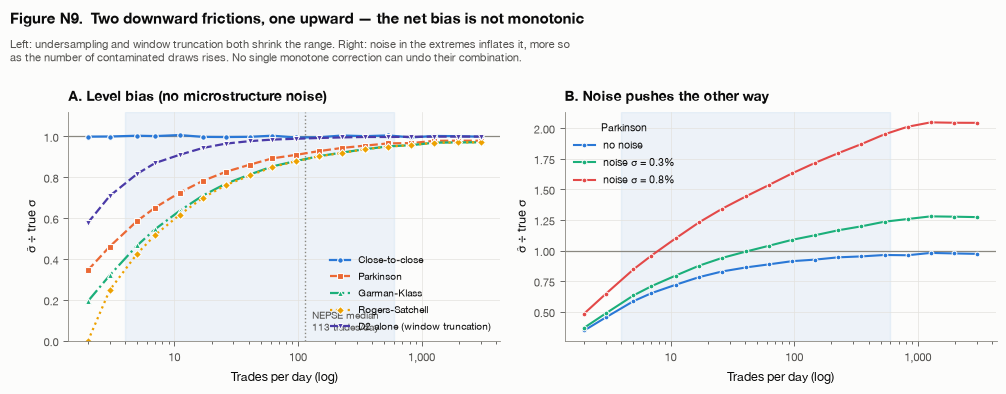

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.9))
p10, p50, p90 = (panel.n_trades.quantile(q) for q in (.10, .50, .90))

ax = axes[0]
ax.axhline(1.0, color=ps.INK_MUTED, lw=0.9)
ax.axvspan(p10, p90, color=ps.SERIES["blue"], alpha=0.07, zorder=0)
ax.axvline(p50, color=ps.INK_MUTED, ls=":", lw=1.0)
for name in EST:
    c, ls, mk = ps.STYLE[name]
    ax.plot(sim_bias.index, sim_bias[name], color=c, ls=ls, marker=mk, ms=4,
            markeredgecolor=ps.SURFACE, markeredgewidth=0.8, label=name)
ax.plot(sim_bias.index, sim_bias["Traded window (D2 alone)"], color=ps.SERIES["violet"],
        ls="--", marker="v", ms=4, markeredgecolor=ps.SURFACE, markeredgewidth=0.8,
        label="D2 alone (window truncation)")
ax.set_xscale("log"); ps.plain_log_axis(ax,"x"); ax.set_ylim(0, 1.12)
ax.legend(fontsize=7.2, loc="lower right")
ax.text(p50*1.15, 0.05, f"NEPSE median\n{p50:.0f} trades/day", fontsize=7.2, color=ps.INK_SOFT)
ps.finish(ax, "A. Level bias (no microstructure noise)", None, "Trades per day (log)", "σ̂ ÷ true σ")

ax = axes[1]
ax.axhline(1.0, color=ps.INK_MUTED, lw=0.9)
ax.axvspan(p10, p90, color=ps.SERIES["blue"], alpha=0.07, zorder=0)
for nz, colr, lbl in [(0.000, ps.SERIES["blue"],  "no noise"),
                      (0.003, ps.SERIES["aqua"],  "noise σ = 0.3%"),
                      (0.008, ps.SERIES["red"],   "noise σ = 0.8%")]:
    ys = []
    for n_tr in GRID:
        vals = []
        for rep in range(5):
            s2 = simulate_observed_ohlc(2500, TRUE_SIGMA, int(n_tr), noise_sd=nz,
                                        seed=99 + rep*17 + int(n_tr))
            v = np.nanmean(R.parkinson(s2))
            vals.append(np.sqrt(v)/TRUE_SIGMA if v > 0 else 0.0)
        ys.append(np.mean(vals))
    ax.plot(GRID, ys, color=colr, marker="o", ms=3.4, lw=1.5,
            markeredgecolor=ps.SURFACE, markeredgewidth=0.7, label=lbl)
ax.set_xscale("log"); ps.plain_log_axis(ax,"x")
ax.legend(fontsize=7.5, title="Parkinson", title_fontsize=7.5)
ps.finish(ax, "B. Noise pushes the other way", None, "Trades per day (log)", "σ̂ ÷ true σ")

ps.header(fig, "Figure N9.  Two downward frictions, one upward — the net bias is not monotonic",
          "Left: undersampling and window truncation both shrink the range. Right: noise in the extremes "
          "inflates it, more so\nas the number of contaminated draws rises. No single monotone correction "
          "can undo their combination.", top=0.83)
plt.show()

In [23]:
# The crossover N*: below it, close-to-close beats every range estimator on RMSE
WINDOW = 21
rmse_rows = []
for n_tr in GRID:
    for rep in range(6):
        sim = simulate_observed_ohlc(N_DAYS, TRUE_SIGMA, int(n_tr), noise_sd=0.0,
                                     seed=777 + rep*53 + int(n_tr))
        for name, fn in EST.items():
            v = pd.Series(np.asarray(fn(sim), dtype=float)).rolling(WINDOW).mean()
            sig = np.sqrt(v.clip(lower=0))
            rmse_rows.append({"n_trades": int(n_tr), "estimator": name,
                              "rmse": float(np.sqrt(np.nanmean((sig - TRUE_SIGMA)**2)))/TRUE_SIGMA})
rm = pd.DataFrame(rmse_rows).groupby(["n_trades","estimator"]).rmse.mean().unstack()

cross = {}
for e in ["Parkinson","Garman-Klass","Rogers-Satchell"]:
    wins = [n for n in rm.index if rm.loc[n,"Close-to-close"] < rm.loc[n, e]]
    cross[e] = max(wins) if wins else None

print("Crossover N* — at or below this trade count, plain close-to-close has LOWER RMSE\n" + "="*78)
for e, nstar in cross.items():
    share = 100*(panel.n_trades <= nstar).mean() if nstar else 0
    print(f"  {e:18} N* = {str(nstar):>5}   →  {share:5.1f}% of NEPSE stock-days fall at or below")
print("\nThe textbook efficiency ranking (Parkinson ≈ 5× close-to-close) REVERSES below N*.")

Crossover N* — at or below this trade count, plain close-to-close has LOWER RMSE
  Parkinson          N* =    41   →   29.7% of NEPSE stock-days fall at or below
  Garman-Klass       N* =    62   →   36.5% of NEPSE stock-days fall at or below
  Rogers-Satchell    N* =    62   →   36.5% of NEPSE stock-days fall at or below

The textbook efficiency ranking (Parkinson ≈ 5× close-to-close) REVERSES below N*.


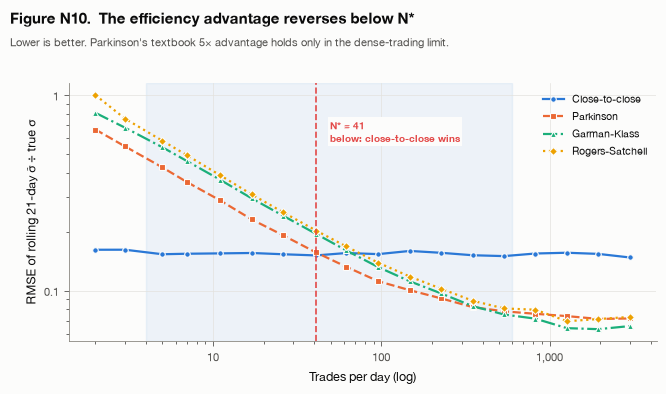

In [24]:
fig, ax = plt.subplots(figsize=(6.6, 3.9))
ax.axvspan(p10, p90, color=ps.SERIES["blue"], alpha=0.07, zorder=0)
for name in EST:
    c, ls, mk = ps.STYLE[name]
    ax.plot(rm.index, rm[name], color=c, ls=ls, marker=mk, ms=4,
            markeredgecolor=ps.SURFACE, markeredgewidth=0.8, label=name)
nstar = cross["Parkinson"]
if nstar:
    ax.axvline(nstar, color=ps.SERIES["red"], ls="--", lw=1.2)
    ax.annotate(f"N* ≈ {nstar}\nbelow: close-to-close wins", (nstar, ax.get_ylim()[1]*0.55),
                textcoords="offset points", xytext=(10, 0), fontsize=7.5,
                color=ps.SERIES["red"], fontweight="bold",
                bbox=dict(fc=ps.SURFACE, ec="none", pad=1.5))
ax.set_xscale("log"); ps.plain_log_axis(ax,"x"); ax.set_yscale("log"); ps.plain_log_axis(ax,"y")
ax.legend(fontsize=7.5)
ps.finish(ax, None, None, "Trades per day (log)", "RMSE of rolling 21-day σ̂ ÷ true σ")
ps.header(fig, "Figure N10.  The efficiency advantage reverses below N*",
          "Lower is better. Parkinson's textbook 5× advantage holds only in the dense-trading limit.", top=0.84)
plt.show()

## Part 10 · Cross-sectional evidence

Does the simulated pattern appear in the real cross-section? Parkinson estimates the
**open-to-close** variance, so the matched unbiased benchmark is the mean squared
open-to-close return — not the close-to-close return, which also contains overnight variance
and would manufacture a ratio below one even with no discretisation bias at all.

In [25]:
NB = 14
panel["bucket"] = pd.qcut(panel.n_trades, NB, labels=False, duplicates="drop")
def ratio(g, col):
    a, b = g[col].mean(), g.var_oc.mean()
    return np.sqrt(a/b) if a > 0 and b > 0 else np.nan

obs = panel.groupby("bucket").apply(lambda g: pd.Series({
    "median_trades": g.n_trades.median(), "n_obs": len(g),
    "Parkinson": ratio(g,"var_pk"), "Garman-Klass": ratio(g,"var_gk"),
    "Rogers-Satchell": ratio(g,"var_rs"),
    "pk_zero_pct": 100*(g.var_pk == 0).mean(),
    "gk_neg_pct": 100*(g.var_gk < 0).mean(),
})).reset_index(drop=True)
obs["predicted (D1+D2)"] = np.interp(np.log(obs.median_trades.clip(2,3000)),
                                     np.log(sim_bias.index.values), sim_bias["Parkinson"].values)
obs["gap"] = obs["Parkinson"] - obs["predicted (D1+D2)"]
print("Observed vs predicted, by liquidity bucket\n" + "="*104)
print(obs.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

Observed vs predicted, by liquidity bucket
 median_trades      n_obs  Parkinson  Garman-Klass  Rogers-Satchell  pk_zero_pct  gk_neg_pct  predicted (D1+D2)    gap
         1.000 15,747.000      0.949         0.929            1.226       65.619       4.966              0.346  0.603
         6.000 10,687.000      0.728         0.590            0.590        5.212       0.936              0.622  0.105
        15.000 12,470.000      0.727         0.588            0.714        0.425       0.096              0.766 -0.039
        30.000 12,053.000      0.991         0.987            1.055        0.083       0.008              0.838  0.153
        49.000 12,916.000      1.054         1.074            1.148        0.008       0.015              0.876  0.178
        73.000 12,776.000      1.076         1.104            1.174        0.016       0.023              0.899  0.176
        99.000 12,544.000      1.047         1.064            1.123        0.000       0.008              0.911  0.136
     

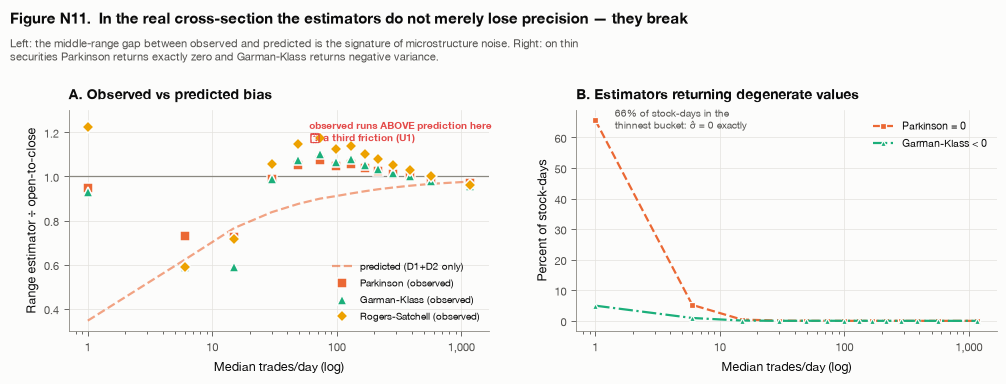

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8))

ax = axes[0]
ax.axhline(1.0, color=ps.INK_MUTED, lw=0.9)
ax.plot(obs.median_trades, obs["predicted (D1+D2)"], color=ps.SERIES["orange"],
        ls="--", lw=1.6, alpha=0.6, label="predicted (D1+D2 only)")
for e in ["Parkinson","Garman-Klass","Rogers-Satchell"]:
    c, ls, mk = ps.STYLE[e]
    ax.plot(obs.median_trades, obs[e], color=c, ls="none", marker=mk, ms=6.5,
            markeredgecolor=ps.SURFACE, markeredgewidth=1.1, label=f"{e} (observed)")
ax.set_xscale("log"); ps.plain_log_axis(ax,"x"); ax.set_ylim(0.3, 1.3)
ax.legend(fontsize=7.2, loc="lower right")
ax.annotate("observed runs ABOVE prediction here\n→ a third friction (U1)", (60, 1.16),
            fontsize=7.2, color=ps.SERIES["red"], fontweight="bold")
ps.finish(ax, "A. Observed vs predicted bias", None, "Median trades/day (log)",
          "Range estimator ÷ open-to-close")

ax = axes[1]
for col, lbl, key in [("pk_zero_pct","Parkinson = 0","Parkinson"),
                      ("gk_neg_pct","Garman-Klass < 0","Garman-Klass")]:
    c, ls, mk = ps.STYLE[key]
    ax.plot(obs.median_trades, obs[col], color=c, ls=ls, marker=mk, ms=5,
            markeredgecolor=ps.SURFACE, markeredgewidth=0.9, label=lbl)
ax.set_xscale("log"); ps.plain_log_axis(ax,"x"); ax.legend(fontsize=7.5)
ax.annotate(f"{obs.pk_zero_pct.iloc[0]:.0f}% of stock-days in the\nthinnest bucket: σ̂ = 0 exactly",
            (obs.median_trades.iloc[0], obs.pk_zero_pct.iloc[0]), textcoords="offset points",
            xytext=(14, -6), fontsize=7.2, color=ps.INK_SOFT)
ps.finish(ax, "B. Estimators returning degenerate values", None, "Median trades/day (log)",
          "Percent of stock-days")

ps.header(fig, "Figure N11.  In the real cross-section the estimators do not merely lose precision — they break",
          "Left: the middle-range gap between observed and predicted is the signature of microstructure noise. "
          "Right: on thin\nsecurities Parkinson returns exactly zero and Garman-Klass returns negative variance.", top=0.83)
plt.show()

In [27]:
# Identify the upward friction directly, using bounce measured per security
import statsmodels.api as sm

per = []
for sym, g in panel.groupby("symbol"):
    if len(g) < 150: continue
    a, b = g.var_pk.mean(), g.var_oc.mean()
    if not (a > 0 and b > 0): continue
    per.append({"symbol": sym, "n_trades": g.n_trades.median(),
                "obs": np.sqrt(a/b), "ac1": g.cc.autocorr(1)})
P = pd.DataFrame(per).dropna()
P["pred"]   = np.interp(np.log(P.n_trades.clip(2,3000)), np.log(sim_bias.index.values),
                        sim_bias["Parkinson"].values)
P["gap"]    = P.obs - P.pred
P["bounce"] = -P.ac1
P["log_n"]  = np.log(P.n_trades)
P = P[np.isfinite(P.gap) & (P.gap.abs() < 2)]

m0 = sm.OLS(P.gap, sm.add_constant(P[["log_n"]])).fit(cov_type="HC1")
m1 = sm.OLS(P.gap, sm.add_constant(P[["bounce","log_n"]])).fit(cov_type="HC1")

print("Does directly measured bid-ask bounce explain the residual gap?\n" + "="*72)
print(f"{'':20}{'(1) liquidity':>18}{'(2) + bounce':>18}")
print(f"{'bounce (−AC₁)':20}{'—':>18}{m1.params['bounce']:>11.3f} ({m1.tvalues['bounce']:>4.1f})")
print(f"{'log trades/day':20}{m0.params['log_n']:>11.3f} ({m0.tvalues['log_n']:>4.1f}){m1.params['log_n']:>11.3f} ({m1.tvalues['log_n']:>4.1f})")
print(f"{'R²':20}{m0.rsquared:>18.3f}{m1.rsquared:>18.3f}")
print(f"{'N securities':20}{int(m0.nobs):>18}{int(m1.nobs):>18}")
print(f"\nbounce p-value = {m1.pvalues['bounce']:.2e}")
print("\nNote the SIGN FLIP on log trades/day between (1) and (2): omitted-variable bias.")
print("Liquidity proxies for BOTH the downward frictions and the upward one, so a correction")
print("indexed on liquidity alone recovers a mixture, not a parameter.")

Does directly measured bid-ask bounce explain the residual gap?
                         (1) liquidity      (2) + bounce
bounce (−AC₁)                        —      0.183 ( 5.2)
log trades/day           -0.049 (-28.3)     -0.039 (-16.1)
R²                               0.696             0.737
N securities                       362               362

bounce p-value = 2.29e-07

Note the SIGN FLIP on log trades/day between (1) and (2): omitted-variable bias.
Liquidity proxies for BOTH the downward frictions and the upward one, so a correction
indexed on liquidity alone recovers a mixture, not a parameter.


## Findings

1. **The index is a well-behaved financial time series** — stationary returns, near-zero
   own-autocorrelation, strong volatility clustering, fat tails, GARCH-estimable with slow
   decay. Nothing exotic.
2. **The cross-section is not.** The median security trades 113 times a day and the tenth
   percentile trades 4. On 6.1% of stock-days the high equals the low, so Parkinson's
   variance is *exactly zero*; in the thinnest decile that reaches 58%.
3. **Three frictions act in two directions.** Undersampling and traded-window truncation
   bias the range down; microstructure noise in the extremes biases it up. The net bias is
   **non-monotonic in liquidity**.
4. **The efficiency ranking reverses below N\*.** Plain close-to-close — which uses no range
   information and is therefore immune to all three frictions — strictly dominates every
   range estimator on a substantial share of NEPSE stock-days.
5. **Liquidity is the wrong conditioning variable.** The sign on trading intensity flips once
   bounce is controlled for. A correction must condition on trading intensity **and** a noise
   measure separately.
6. **The model-based route survives.** GARCH converges across all liquidity groups, so the
   recommendation is unambiguous: below N\*, use close-to-close or a conditional-volatility
   model — never a range estimator.

## What this notebook does not establish

- **No external validation.** The S&P 500 and Nifty 50 rungs are not built. Until the
  extrapolation is tested against a market where ground truth exists, these numbers rest on
  simulation plus one market.
- **Circuit-breaker censoring is unmodelled** — a fourth friction, absent from the decomposition.
- **Bounce is measured with −AC₁**, which also absorbs genuine short-horizon reversal.
  Separating the two needs trade-level data.
- **The 1-trade bucket is not identified** — with a single transaction O = H = L = C, so
  numerator and denominator degenerate together.
- **No pre-analysis plan is frozen.** Everything above is exploratory.